### Objective

This notebook evaluates the quality of predicted probabilities produced by the
baseline credit risk model. We focus on probability calibration, uncertainty,
and decision reliability rather than classification accuracy.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score, RocCurveDisplay
from sklearn.pipeline import Pipeline

In [2]:
model = joblib.load('C:/Users/Pratik/DS/credit-risk-ml/models/logreg_baseline.joblib')
preprocessor = model.named_steps['preprocess']

X_test, y_test = joblib.load('C:/Users/Pratik/DS/credit-risk-ml/models/test_data.joblib')

X_train, y_train = joblib.load('C:/Users/Pratik/DS/credit-risk-ml/models/train_data.joblib')

In [3]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

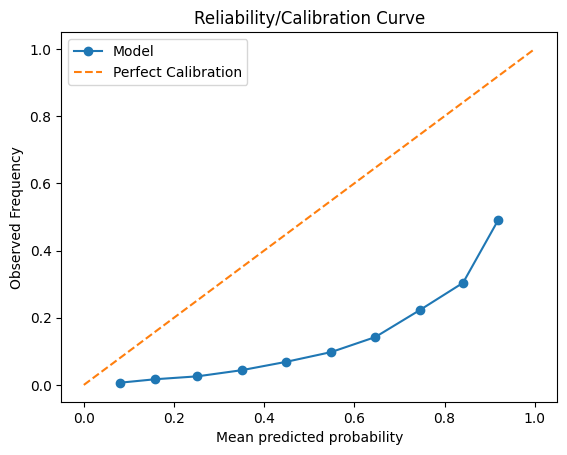

In [4]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
plt.plot(prob_pred, prob_true, marker = 'o', label='Model')
plt.plot([0,1],[0,1],linestyle='--',label='Perfect Calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.title("Reliability/Calibration Curve")
plt.show()

In [5]:
# Calculating ECE - Expected Calibration Error

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_prob = np.clip(y_prob, 0, 1 - 1e-8)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for m in range(n_bins):
        bin_mask = (bin_ids == m)
        if np.any(bin_mask):
            bin_acc = y_true[bin_mask].mean()
            bin_conf = y_prob[bin_mask].mean()
            ece += np.sum(bin_mask) / len(y_true) * np.abs(bin_acc - bin_conf)
    return ece

ece = expected_calibration_error(y_test, y_proba)
print(f"Expected Calibration Error (ECE): {ece}")

Expected Calibration Error (ECE): 0.3461910689165631


In [6]:
# Brier Score 
brier = brier_score_loss(y_test, y_proba)
print(f"Brier score: {brier}")

Brier score: 0.2048749897285172


In [7]:
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:\n", roc_auc)

ROC-AUC:
 0.7433043010009185


### Calibration Methods
- Platt
- Isotonic


In [8]:
# Platt Calibration
platt = CalibratedClassifierCV(
    model, method='sigmoid', cv=5
)
platt.fit(X_train,y_train)
joblib.dump(platt, "C:/Users/Pratik/DS/credit-risk-ml/models/logreg_platt.joblib")
y_prob_platt = platt.predict_proba(X_test)[:, 1]

In [9]:
iso = CalibratedClassifierCV(
    model, method="isotonic", cv= 5
)
iso.fit(X_train, y_train)
y_prob_iso = iso.predict_proba(X_test)[:, 1]

In [10]:
ece_platt = expected_calibration_error(y_test, y_prob_platt)
brier_platt = brier_score_loss(y_test, y_prob_platt)
roc_auc_platt = roc_auc_score(y_test, y_prob_platt)

ece_iso = expected_calibration_error(y_test, y_prob_iso)
brier_iso = brier_score_loss(y_test, y_prob_iso)
roc_auc_iso = roc_auc_score(y_test, y_prob_iso)

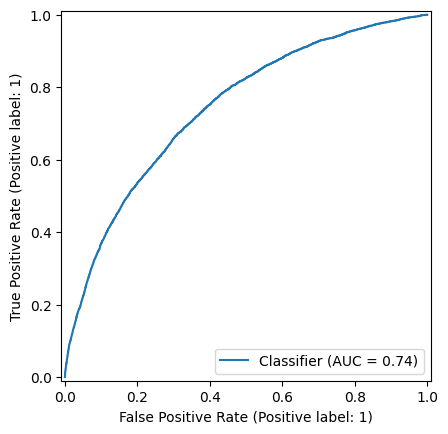

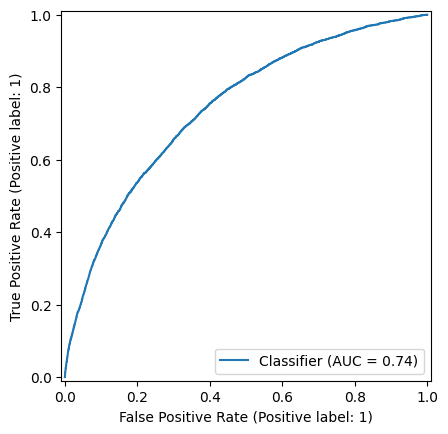

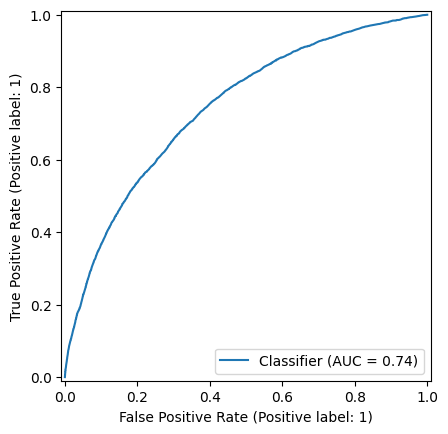

In [11]:
roc_base_disp = RocCurveDisplay.from_predictions(y_test, y_proba)
roc_platt_disp = RocCurveDisplay.from_predictions(y_test, y_prob_platt)
roc_iso_disp = RocCurveDisplay.from_predictions(y_test, y_prob_iso)

In [12]:
comparison = pd.DataFrame({
    'Model':[
        'Baseline',
        'Platt-Calibrated',
        'Iso-calibrated'
    ],
    'ROC-AUC':[
        roc_auc,
        roc_auc_platt,
        roc_auc_iso
    ],
    'ECE':[
        ece,
        ece_platt,
        ece_iso
    ],
    'Brier':[
        brier,
        brier_platt,
        brier_iso
    ]
})
comparison

,Model,ROC-AUC,ECE,Brier
0,Baseline,0.743304,0.346191,0.204875
1,Platt-Calibrated,0.743479,0.001785,0.068790
2,Iso-calibrated,0.743528,0.001870,0.068777


Observations :
AUC score remains similar, Platt imporves ECE slightly when compared to Isotonic. The brier scores are same for both

In [13]:
pd_series = pd.Series(y_prob_platt, name='PD')
risk_bucket = pd.cut(
    pd_series,
    bins = [0, 0.10, 0.30, 1.0],
    labels = ['Low','Medium','High'],
    right=False
)
risk_bucket

0           Low
1           Low
2        Medium
3        Medium
4           Low
          ...  
61498       Low
61499       Low
61500       Low
61501    Medium
61502    Medium
Name: PD, Length: 61503, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [14]:
risk_df = pd.DataFrame({
    'PD':y_prob_platt,
    'TARGET': y_test.values,
    'RiskBucket': risk_bucket
})
risk_df

,PD,TARGET,RiskBucket
0,0.053552,0,Low
1,0.041810,0,Low
2,0.187116,0,Medium
3,0.120004,0,Medium
4,0.078284,0,Low
...,...,...,...
61498,0.069008,0,Low
61499,0.055929,0,Low
61500,0.056546,0,Low
61501,0.125255,1,Medium


In [15]:
bucket_summary = (
    risk_df.groupby("RiskBucket", observed=False).agg(
        count=('TARGET','size'),
        Avg_PD=('PD','mean'),
        default_rate=('TARGET','mean')
    )
    .sort_values('Avg_PD')
)
bucket_summary

,count,Avg_PD,default_rate
RiskBucket,,,
Low,45601,0.046818,0.046381
Medium,14581,0.158447,0.161717
High,1321,0.375858,0.372445


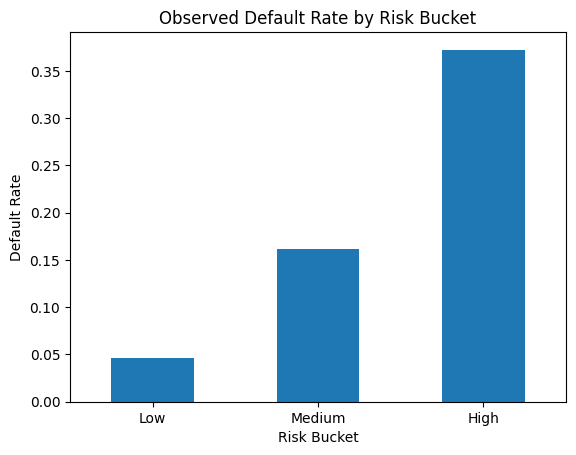

In [16]:
bucket_summary["default_rate"].plot(
    kind="bar",
    title="Observed Default Rate by Risk Bucket",
    ylabel="Default Rate",
    xlabel="Risk Bucket",
    rot=0
)
plt.show()

In [17]:
bucket_summary["population_share"] = (bucket_summary["count"] / bucket_summary["count"].sum())
bucket_summary

,count,Avg_PD,default_rate,population_share
RiskBucket,,,,
Low,45601,0.046818,0.046381,0.741444
Medium,14581,0.158447,0.161717,0.237078
High,1321,0.375858,0.372445,0.021479


In [20]:
bucket_summary.to_csv("C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/risk_bucket_summary.csv",index=True)

- Baseline model ranks risk well but is miscalibrated
- Calibration improves probability trustworthiness
- Reliable probabilities help enable risk segmentation & policy decisions